# Predictive Maintenance Analysis using Python

## Import Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [11]:
df = pd.read_csv('predictive_maintenance.csv')

In [12]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## Check Dataset Information

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


## Basic Statistics

In [14]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


## Failure Distribution Analysis

In [15]:
print(df['Failure Type'].value_counts())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


## Visualization (Failure Distribution)

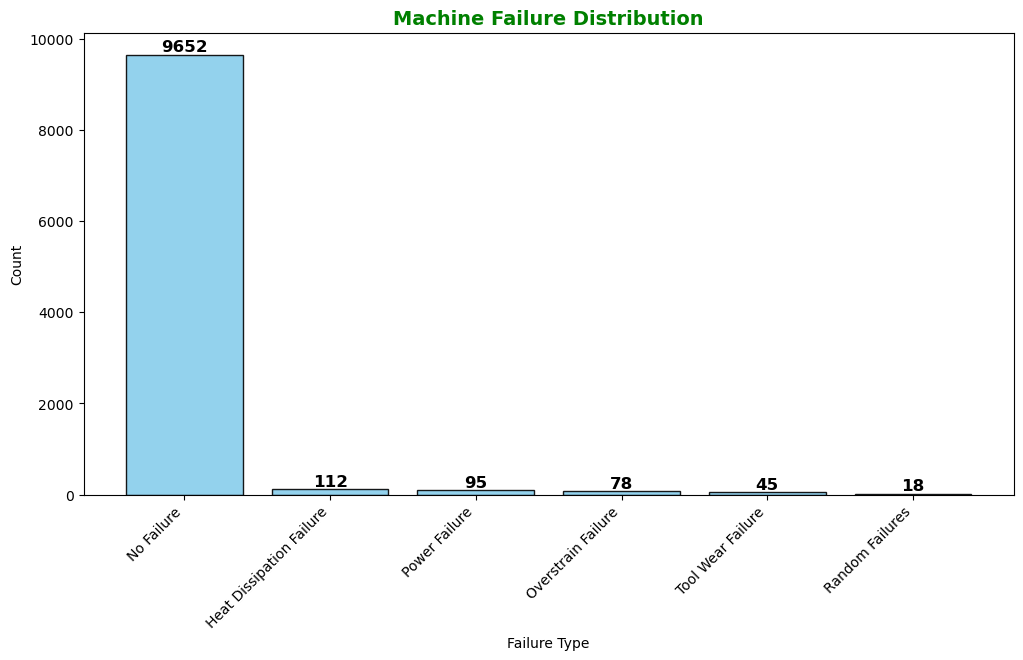

In [24]:
failure_counts = df['Failure Type'].value_counts()
plt.figure(figsize =(12,6))

bars = plt.bar(failure_counts.index, failure_counts.values,
               color = 'skyblue', edgecolor = 'black', alpha=0.9)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{int(height)}',
        ha = 'center',
        va = 'bottom',
        fontweight = 'bold',
        fontsize = 12,
    )

plt.title('Machine Failure Distribution', fontsize = 14, fontweight = 'bold', color = 'g')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha = 'right')
plt.show()

## Torque vs Machine Failure

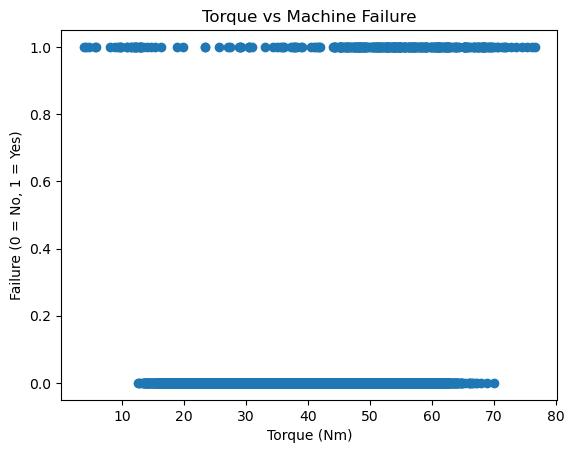

In [25]:
plt.scatter(df['Torque [Nm]'], df['Target'])

plt.title('Torque vs Machine Failure')
plt.xlabel('Torque (Nm)')
plt.ylabel('Failure (0 = No, 1 = Yes)')

plt.show()

## Tool Wear Analysis

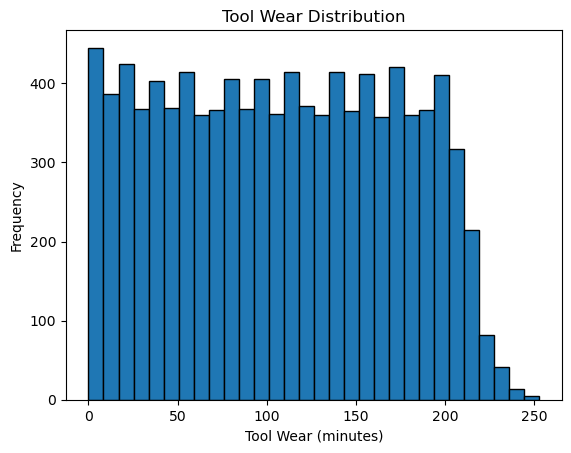

In [28]:
plt.hist(df['Tool wear [min]'], bins = 30, edgecolor='black')

plt.title('Tool Wear Distribution')
plt.xlabel('Tool Wear (minutes)')
plt.ylabel('Frequency')

plt.show()

## Correlation Analysis

In [30]:
corr = df.corr(numeric_only = True)
print(corr['Target'].sort_values(ascending=False))

Target                     1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Target, dtype: float64


## Failure vs Machine Type

In [31]:
failure_by_type = df.groupby('Type')['Target'].sum()

print(failure_by_type)

Type
H     21
L    235
M     83
Name: Target, dtype: int64


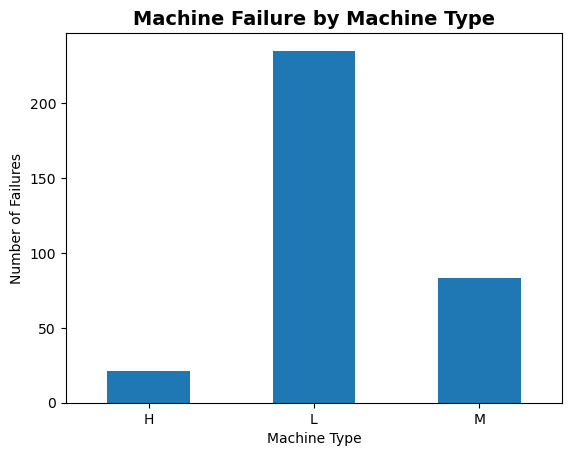

In [35]:
failure_by_type.plot(kind = 'bar')

plt.title('Machine Failure by Machine Type', fontsize =14, fontweight ='bold')
plt.xlabel('Machine Type')
plt.xticks(rotation=0)
plt.ylabel('Number of Failures')

plt.show()

## Machine Learning Model

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [38]:
X = df[['Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]']]
y = df['Target']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2, random_state = 42)

In [41]:
X_train.shape, X_test.shape

((8000, 5), (2000, 5))

In [42]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [43]:
accuracy = model.score(X_test, y_test)
print('Model Accuracy : ', accuracy)

Model Accuracy :  0.9845


## Feature Importance

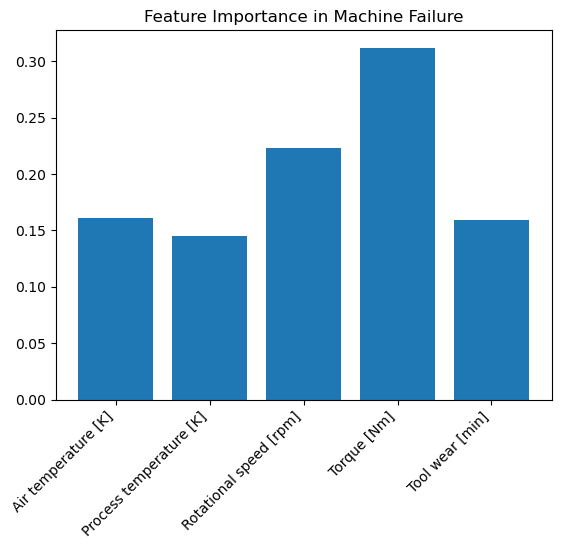

In [45]:
importance = model.feature_importances_
features = X.columns
plt.bar(features, importance)
plt.title ('Feature Importance in Machine Failure')
plt.xticks(rotation = 45, ha = 'right')
plt.show()